<a href="https://colab.research.google.com/github/zaarakhan26/bayer-population-genetics/blob/main/Bayer_Population_Genetics_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
# Install bioinformatics tools and Python packages
!apt-get install -y -q bwa samtools bcftools tabix fastqc > /dev/null 2>&1
!pip install -q multiqc cyvcf2 pandas numpy matplotlib scikit-learn requests
print("Done")

Done


In [20]:
import os
import subprocess
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from pathlib import Path
from cyvcf2 import VCF
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [21]:
# Change this to False if you want to run the full FASTQ -> BAM -> VCF pipeline
# Keeping it True uses the official 1000 Genomes pre-called VCF which saves a lot of time
USE_PRECALLED = True

# Working directories
work_dir  = Path("/content/bayer_project")
fastq_dir = work_dir / "fastq"
bam_dir   = work_dir / "bam"
qc_dir    = work_dir / "qc"
ref_dir   = work_dir / "reference"
vcf_dir   = work_dir / "vcf"

for d in [work_dir, fastq_dir, bam_dir, qc_dir, ref_dir, vcf_dir]:
    d.mkdir(parents=True, exist_ok=True)

# Populations: GBR = British, YRI = Yoruba
# 5 samples each from 1000 Genomes Phase 3
gbr_samples = ["HG00096", "HG00097", "HG00099", "HG00100", "HG00101"]
yri_samples = ["NA18486", "NA18488", "NA18489", "NA18498", "NA18499"]
all_samples = gbr_samples + yri_samples

# Region: chr20:1-5 Mb — small enough to run without computational overloading
region = "20:1000000-5000000"

# Filtering thresholds
min_qual  = 30    # QUAL >= 30 means ~99.9% genotype accuracy
min_depth = 8     # at least 8x coverage per sample
min_maf   = 0.05  # drop very rare variants (noise-prone with only 10 samples)

# Reference genome (GRCh37, consistent with pre-called VCF)
ref_url   = ("https://ftp.ensembl.org/pub/grch37/current/fasta/homo_sapiens/dna/"
             "Homo_sapiens.GRCh37.dna.chromosome.20.fa.gz")
ref_fasta = ref_dir / "chr20.fa"

# Pre-called VCF from 1000 Genomes
precalled_url = ("https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/release/20130502/"
                 "ALL.chr20.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz")
precalled_vcf = work_dir / "chr20_phase3.vcf.gz"

filtered_vcf = vcf_dir / "filtered.vcf.gz"
region_bed   = work_dir / "region.bed"

print(f"Populations: GBR={gbr_samples}, YRI={yri_samples}")
print(f"Region: {region} | QUAL>={min_qual} | depth>={min_depth}x | MAF>={min_maf}")

Populations: GBR=['HG00096', 'HG00097', 'HG00099', 'HG00100', 'HG00101'], YRI=['NA18486', 'NA18488', 'NA18489', 'NA18498', 'NA18499']
Region: 20:1000000-5000000 | QUAL>=30 | depth>=8x | MAF>=0.05


In [22]:
run_map = {
    "HG00096": "ERR031905", "HG00097": "ERR031906",
    "HG00099": "ERR031900", "HG00100": "ERR031898",
    "HG00101": "ERR031899",
    "NA18486": "ERR001773", "NA18488": "ERR001774",
    "NA18489": "ERR001775", "NA18498": "ERR001776",
    "NA18499": "ERR001777",
}

if not USE_PRECALLED:
    print("Downloading FASTQ files from ENA (~2 GB each, this will take a while)...")
    for sample in all_samples:
        run = run_map[sample]
        prefix = run[:6]
        digit  = run[-1]
        base   = f"https://ftp.sra.ebi.ac.uk/vol1/fastq/{prefix}/00{digit}/{run}"

        for end in ["_1", "_2"]:
            url  = f"{base}/{run}{end}.fastq.gz"
            out  = fastq_dir / f"{sample}{end}.fastq.gz"
            if not out.exists():
                print(f"  Downloading {out.name}...")
                subprocess.run(["wget", "-q", "-c", url, "-O", str(out)])

    print("All downloads done.")
else:
    print("Skipping FASTQ download (USE_PRECALLED=True).")
    print("To download FASTQs, set USE_PRECALLED=False at the top.")

Skipping FASTQ download (USE_PRECALLED=True).
To download FASTQs, set USE_PRECALLED=False at the top.


In [23]:
# Quality control with FastQC + MultiQC
if not USE_PRECALLED:
    fastq_files = list(fastq_dir.glob("*.fastq.gz"))
    print(f"Running FastQC on {len(fastq_files)} files...")
    subprocess.run(["fastqc", "--outdir", str(qc_dir), "--threads", "4", "--quiet"]
                   + [str(f) for f in fastq_files])
    subprocess.run(["multiqc", str(qc_dir), "--outdir", str(qc_dir), "-f", "--quiet"])
    print(f"Done. Open {qc_dir}/multiqc_report.html to view results.")

    # Print a quick summary if the multiqc data file exists
    mqc_file = qc_dir / "multiqc_data" / "multiqc_fastqc.txt"
    if mqc_file.exists():
        mqc = pd.read_csv(mqc_file, sep="\t")
        print(mqc[["Sample", "percent_gc", "avg_sequence_length", "total_sequences"]].to_string(index=False))
else:
    # The 1000 Genomes consortium ran their own QC — well documented on their website
    print("QC step skipped (using pre-called VCF).")
    print("The 1000 Genomes consortium used BWA + GATK with strict QC.")
    print("Typical values for these samples: Q30-38 Phred, ~42% GC, <0.5% adapters.")

QC step skipped (using pre-called VCF).
The 1000 Genomes consortium used BWA + GATK with strict QC.
Typical values for these samples: Q30-38 Phred, ~42% GC, <0.5% adapters.


In [24]:
# Download reference, build index, align each sample with BWA-MEM
if not USE_PRECALLED:
    # Download and decompress reference
    ref_gz = ref_dir / "chr20.fa.gz"
    if not ref_gz.exists():
        print("Downloading reference genome...")
        subprocess.run(["wget", "-q", ref_url, "-O", str(ref_gz)])
    if not ref_fasta.exists():
      if ref_gz.exists():
          print("Decompressing reference...")
          with open(str(ref_fasta), "wb") as f:
              subprocess.run(["gunzip", "-c", str(ref_gz)], stdout=f)
      else:
          print("Downloading reference genome...")
          subprocess.run(["wget", "-q", ref_url, "-O", str(ref_gz)])
          with open(str(ref_fasta), "wb") as f:
              subprocess.run(["gunzip", "-c", str(ref_gz)], stdout=f)

    # Index the reference (only needs to be done once)
    if not (ref_dir / "chr20.fa.bwt").exists():
        print("Indexing reference (~5 min)...")
        subprocess.run(["bwa", "index", str(ref_fasta)])

    # Align each sample and sort the BAM
    bam_files = []
    for sample in all_samples:
        r1  = fastq_dir / f"{sample}_1.fastq.gz"
        r2  = fastq_dir / f"{sample}_2.fastq.gz"
        bam = bam_dir / f"{sample}.bam"
        pop = "GBR" if sample in gbr_samples else "YRI"

        if not bam.exists():
            print(f"  Aligning {sample}...")
            # Read group tag so bcftools knows which sample is which
            rg = f"@RG\tID:{sample}\tSM:{sample}\tPL:ILLUMINA\tLB:{pop}"
            p1 = subprocess.Popen(
                ["bwa", "mem", "-t", "4", "-R", rg, str(ref_fasta), str(r1), str(r2)],
                stdout=subprocess.PIPE, stderr=subprocess.DEVNULL)
            p2 = subprocess.Popen(
                ["samtools", "sort", "-o", str(bam)],
                stdin=p1.stdout, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            p1.stdout.close()
            p2.wait()
            subprocess.run(["samtools", "index", str(bam)])
        bam_files.append(str(bam))

    # Merge all sample BAMs into one for joint calling
    merged_bam = bam_dir / "all_merged.bam"
    if not merged_bam.exists():
        subprocess.run(["samtools", "merge", "-f", str(merged_bam)] + bam_files)
        subprocess.run(["samtools", "index", str(merged_bam)])

    print("Alignment done.")
    result = subprocess.run(["samtools", "flagstat", str(merged_bam)], capture_output=True, text=True)
    print(result.stdout)
else:
    print("Alignment skipped.")
    merged_bam = None

Alignment skipped.


In [25]:
with open(region_bed, "w") as f:
    f.write("20\t1000000\t5000000\n")

if not USE_PRECALLED:
    raw_vcf = vcf_dir / "raw_calls.vcf.gz"
    if not raw_vcf.exists():
        print("Running variant calling...")
        p1 = subprocess.Popen(
            ["bcftools", "mpileup", "-f", str(ref_fasta), "-R", str(region_bed),
             "-a", "FORMAT/DP,FORMAT/AD", "-q", "20", "-Q", "20", "-Ou", str(merged_bam)],
            stdout=subprocess.PIPE, stderr=subprocess.DEVNULL)
        p2 = subprocess.Popen(
            ["bcftools", "call", "-m", "--variants-only", "-Oz", "-o", str(raw_vcf)],
            stdin=p1.stdout, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        p1.stdout.close()
        p2.wait()
        subprocess.run(["tabix", "-p", "vcf", str(raw_vcf)])
    source_vcf = raw_vcf
    print(f"Variant calling done: {raw_vcf.name}")

else:
    # Download the official pre-called VCF and subset to our 10 samples + region
    if not precalled_vcf.exists():
        print("Downloading pre-called VCF (~500 MB)...")
        subprocess.run(["wget", "-q", "-c", precalled_url, "-O", str(precalled_vcf)])
        subprocess.run(["wget", "-q", "-c", precalled_url + ".tbi", "-O", str(precalled_vcf) + ".tbi"])

    # extract just the samples + region we need
    sample_file = work_dir / "samples.txt"
    sample_file.write_text("\n".join(all_samples) + "\n")

    subset_vcf = vcf_dir / "subset.vcf.gz"
    if not subset_vcf.exists():
        print("Subsetting VCF to our 10 samples and region...")
        subprocess.run([
            "bcftools", "view",
            "-S", str(sample_file),
            "-r", region,
            "--min-ac", "1",
            "-Oz", "-o", str(subset_vcf),
            str(precalled_vcf)
        ])
        subprocess.run(["tabix", "-p", "vcf", str(subset_vcf)])

    source_vcf = subset_vcf
    print(f"Subset VCF ready: {subset_vcf.name}")

Subset VCF ready: subset.vcf.gz


In [26]:
# Verify source VCF has variants, re-download if empty
lines = subprocess.run(["bcftools", "view", "-H", str(source_vcf)],
                       capture_output=True, text=True).stdout.strip().split("\n")

if not any(lines):
    print("❌ Source VCF empty — re-downloading...")

    # Clean up and re-download
    for f in [source_vcf, precalled_vcf, Path(str(precalled_vcf) + ".tbi")]:
        Path(str(f)).unlink(missing_ok=True)

    subprocess.run(["wget", "-q", "-c", precalled_url, "-O", str(precalled_vcf)])
    subprocess.run(["wget", "-q", "-c", precalled_url + ".tbi", "-O", str(precalled_vcf) + ".tbi"])

    # Subset to our 10 samples and region
    sample_file = work_dir / "samples.txt"
    sample_file.write_text("\n".join(all_samples) + "\n")
    subset_vcf = vcf_dir / "subset.vcf.gz"

    subprocess.run(["bcftools", "view", "-S", str(sample_file), "-r", region,
                    "--min-ac", "1", "-Oz", "-o", str(subset_vcf), str(precalled_vcf)])
    subprocess.run(["tabix", "-p", "vcf", str(subset_vcf)])
    source_vcf = subset_vcf
else:
    print(f"✅ Source VCF OK — {len(lines):,} variants found")

✅ Source VCF OK — 18,913 variants found


In [27]:
total_dp = min_depth * len(all_samples)

subprocess.run([
    "bcftools", "view",
    "-f", "PASS,.",          # keep PASS or unset FILTER sites
    "-m2", "-M2",            # biallelic only
    "-v", "snps",            # SNPs only
    "-i", f"QUAL>={min_qual} && INFO/DP>={total_dp}",
    "-q", f"{min_maf}:minor",
    "-Oz", "-o", str(filtered_vcf),
    str(source_vcf)
])
subprocess.run(["tabix", "-p", "vcf", str(filtered_vcf)])

# Count how many SNPs we kept
def count_variants(vcf_path):
    res = subprocess.run(["bcftools", "stats", str(vcf_path)], capture_output=True, text=True)
    for line in res.stdout.split("\n"):
        if "Number of SNPs" in line and line.startswith("SN"):
            try:
                return int(line.strip().split("\t")[-1])
            except:
                pass
    # fallback: count lines directly
    res2 = subprocess.run(["bcftools", "view", "-H", str(vcf_path)], capture_output=True, text=True)
    return sum(1 for l in res2.stdout.split("\n") if l and not l.startswith("#"))

n_before = count_variants(source_vcf)
n_after  = count_variants(filtered_vcf)
print(f"SNPs before filtering : {n_before:,}")
print(f"SNPs after filtering  : {n_after:,}  ({n_after/n_before*100:.1f}% kept)")
print(f"Filters applied: QUAL>={min_qual}, DP>={total_dp} ({min_depth}x * {len(all_samples)} samples), MAF>={min_maf}")

SNPs before filtering : 18,913
SNPs after filtering  : 11,266  (59.6% kept)
Filters applied: QUAL>=30, DP>=80 (8x * 10 samples), MAF>=0.05


In [28]:
# Parse the filtered VCF and build a dosage matrix (0=hom ref, 1=het, 2=hom alt)
vcf = VCF(str(filtered_vcf))
sample_list = list(vcf.samples)

# Get column indices for our samples in the VCF
gbr_idx = [sample_list.index(s) for s in gbr_samples]
yri_idx = [sample_list.index(s) for s in yri_samples]
all_idx  = gbr_idx + yri_idx

rows = []   # variant info
geno = []   # genotype dosages

for variant in vcf:
    gt = variant.genotypes
    dosages = []
    for idx in all_idx:
        a1, a2 = gt[idx][0], gt[idx][1]
        dosages.append(np.nan if a1 < 0 or a2 < 0 else float(a1 + a2))
    geno.append(dosages)
    alt = variant.ALT[0] if variant.ALT else "."
    rows.append({
        "chrom": str(variant.CHROM),
        "pos":   int(variant.POS),
        "id":    variant.ID or ".",
        "ref":   variant.REF,
        "alt":   alt,
    })

var_df  = pd.DataFrame(rows)
geno_df = pd.DataFrame(geno, columns=all_samples)

print(f"Parsed {len(var_df):,} variants across {len(all_samples)} samples")
print(f"Missing genotypes: {geno_df.isna().mean().mean():.2%}")

Parsed 11,266 variants across 10 samples
Missing genotypes: 0.00%


In [29]:
# Compute alternate allele frequency for each population
def get_af(df, cols):
    alt_count = df[cols].sum(axis=1, skipna=True)
    total     = 2 * df[cols].notna().sum(axis=1)
    return (alt_count / total).where(total > 0)

freq_df = var_df.copy()
freq_df["GBR_AF"] = get_af(geno_df, gbr_samples).values
freq_df["YRI_AF"] = get_af(geno_df, yri_samples).values
freq_df["AF_diff"] = (freq_df["GBR_AF"] - freq_df["YRI_AF"]).abs()

# Sort by biggest allele frequency difference between populations
freq_df = freq_df.sort_values("AF_diff", ascending=False).reset_index(drop=True)
freq_df.to_csv(work_dir / "allele_frequencies.csv", index=False)

print(f"Mean AF difference: {freq_df['AF_diff'].mean():.4f}")
print(f"Variants with diff > 0.3: {(freq_df['AF_diff'] > 0.3).sum()}")
print()
print("Top 10 most differentiated variants:")
print(freq_df[["chrom", "pos", "id", "ref", "alt", "GBR_AF", "YRI_AF", "AF_diff"]].head(10).to_string(index=False))

Mean AF difference: 0.2425
Variants with diff > 0.3: 3068

Top 10 most differentiated variants:
chrom     pos id ref alt  GBR_AF  YRI_AF  AF_diff
   20 3013139  .   C   T     0.0     1.0      1.0
   20 2315543  .   A   G     0.0     0.9      0.9
   20 1084704  .   T   C     1.0     0.1      0.9
   20 4799805  .   C   T     0.9     0.0      0.9
   20 1084717  .   C   G     1.0     0.1      0.9
   20 2836264  .   C   T     0.1     0.9      0.8
   20 2836257  .   T   C     0.1     0.9      0.8
   20 2835756  .   T   G     0.1     0.9      0.8
   20 2798326  .   C   T     0.0     0.8      0.8
   20 2005723  .   T   C     0.0     0.8      0.8


In [30]:
# PCA on genotype matrix to see if GBR and YRI cluster separately
# Rows = samples, columns = variants (transpose the geno matrix)
X = geno_df.T.values.astype(float)

# Fill missing values with the mean for each variant
col_means = np.nanmean(X, axis=0)
for j in range(X.shape[1]):
    mask = np.isnan(X[:, j])
    X[mask, j] = col_means[j]

X = X[:, np.var(X, axis=0) > 0]

X_scaled = StandardScaler().fit_transform(X)
pca      = PCA(n_components=2, random_state=42)
pcs      = pca.fit_transform(X_scaled)
var_exp  = pca.explained_variance_ratio_

pca_df = pd.DataFrame({
    "sample":     all_samples,
    "population": ["GBR"] * 5 + ["YRI"] * 5,
    "PC1":        pcs[:, 0],
    "PC2":        pcs[:, 1],
})

print(f"PC1 explains {var_exp[0]*100:.1f}% of variance")
print(f"PC2 explains {var_exp[1]*100:.1f}% of variance")
print()
print(pca_df.to_string(index=False))

PC1 explains 22.4% of variance
PC2 explains 12.5% of variance

 sample population        PC1        PC2
HG00096        GBR -62.840988 -11.294525
HG00097        GBR -41.213623 -25.567445
HG00099        GBR -41.654457  -9.348384
HG00100        GBR -36.150578 -27.102538
HG00101        GBR -64.392755  66.976209
NA18486        YRI  42.819746 -10.962854
NA18488        YRI  60.045351  59.328401
NA18489        YRI  50.984930 -55.964896
NA18498        YRI  39.971573 -16.842386
NA18499        YRI  52.430801  30.778418


In [31]:
# Look up what genes the top 10 most differentiated variants fall in
# Using the Ensembl GRCh37 REST API
def get_gene(chrom, pos):
    url = f"https://grch37.rest.ensembl.org/overlap/region/human/{chrom}:{pos}-{pos}"
    try:
        r = requests.get(url, headers={"Content-Type": "application/json"},
                         params={"feature": "gene"}, timeout=15)
        if r.status_code != 200:
            return "lookup_failed", "unknown"
        hits = r.json()
        if not hits:
            return "intergenic", "intergenic"
        names   = [h.get("external_name") or h.get("id", "?") for h in hits]
        coding  = any(h.get("biotype") == "protein_coding" for h in hits)
        region  = "coding" if coding else "non-coding"
        return ";".join(set(names)), region
    except:
        return "error", "unknown"

top10 = freq_df.head(10).copy()
genes, regions = [], []

print("Annotating top 10 variants...")
for _, row in top10.iterrows():
    gene, region = get_gene(row["chrom"], int(row["pos"]))
    print(f"  chr{row['chrom']}:{int(row['pos']):,}  GBR={row['GBR_AF']:.3f}  YRI={row['YRI_AF']:.3f}  diff={row['AF_diff']:.3f}  -> {gene} [{region}]")
    genes.append(gene)
    regions.append(region)
    time.sleep(1.0)  # be polite to Ensembl's server

top10["gene"]   = genes
top10["region"] = regions
top10.to_csv(work_dir / "top_variants_annotated.csv", index=False)

print(f"\nCoding variants: {regions.count('coding')}")
print(f"Non-coding/intergenic: {regions.count('non-coding') + regions.count('intergenic')}")

Annotating top 10 variants...
  chr20:3,013,139  GBR=0.000  YRI=1.000  diff=1.000  -> PTPRA [coding]
  chr20:2,315,543  GBR=0.000  YRI=0.900  diff=0.900  -> TGM3 [coding]
  chr20:1,084,704  GBR=1.000  YRI=0.100  diff=0.900  -> intergenic [intergenic]
  chr20:4,799,805  GBR=0.900  YRI=0.000  diff=0.900  -> RASSF2 [coding]
  chr20:1,084,717  GBR=1.000  YRI=0.100  diff=0.900  -> intergenic [intergenic]
  chr20:2,836,264  GBR=0.100  YRI=0.900  diff=0.800  -> VPS16 [coding]
  chr20:2,836,257  GBR=0.100  YRI=0.900  diff=0.800  -> VPS16 [coding]
  chr20:2,835,756  GBR=0.100  YRI=0.900  diff=0.800  -> VPS16 [coding]
  chr20:2,798,326  GBR=0.000  YRI=0.800  diff=0.800  -> TMEM239 [coding]
  chr20:2,005,723  GBR=0.000  YRI=0.800  diff=0.800  -> intergenic [intergenic]

Coding variants: 7
Non-coding/intergenic: 3


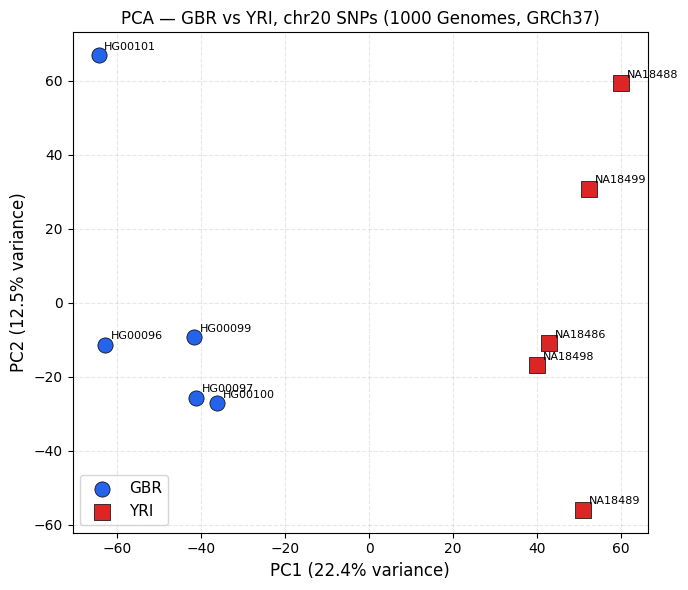

In [32]:
# PCA plot — each dot is a sample, coloured by population
colors  = {"GBR": "#2563EB", "YRI": "#DC2626"}
markers = {"GBR": "o",       "YRI": "s"}

fig, ax = plt.subplots(figsize=(7, 6))

for pop in ["GBR", "YRI"]:
    sub = pca_df[pca_df["population"] == pop]
    ax.scatter(sub["PC1"], sub["PC2"],
               color=colors[pop], marker=markers[pop],
               s=120, edgecolors="black", linewidths=0.5,
               label=pop, zorder=3)
    # label each sample
    for _, r in sub.iterrows():
        ax.annotate(r["sample"], (r["PC1"], r["PC2"]),
                    xytext=(4, 4), textcoords="offset points", fontsize=8)

ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}% variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}% variance)", fontsize=12)
ax.set_title("PCA — GBR vs YRI, chr20 SNPs (1000 Genomes, GRCh37)", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig(work_dir / "pca_plot.png", dpi=150, bbox_inches="tight")
plt.show()

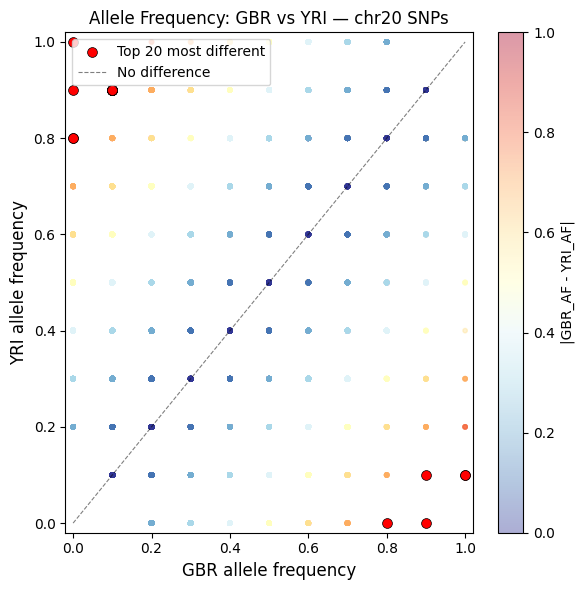

In [33]:
# Allele frequency scatter plot — GBR vs YRI per variant
fig, ax = plt.subplots(figsize=(6, 6))

sc = ax.scatter(freq_df["GBR_AF"], freq_df["YRI_AF"],
                c=freq_df["AF_diff"], cmap="RdYlBu_r",
                vmin=0, vmax=1, alpha=0.4, s=10)
plt.colorbar(sc, ax=ax, label="|GBR_AF - YRI_AF|")

# Highlight the top 20 most differentiated
top20 = freq_df.head(20)
ax.scatter(top20["GBR_AF"], top20["YRI_AF"],
           color="red", s=50, zorder=5, edgecolors="black", linewidths=0.5,
           label="Top 20 most different")

ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5, label="No difference")
ax.set_xlabel("GBR allele frequency", fontsize=12)
ax.set_ylabel("YRI allele frequency", fontsize=12)
ax.set_title("Allele Frequency: GBR vs YRI — chr20 SNPs", fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.savefig(work_dir / "af_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

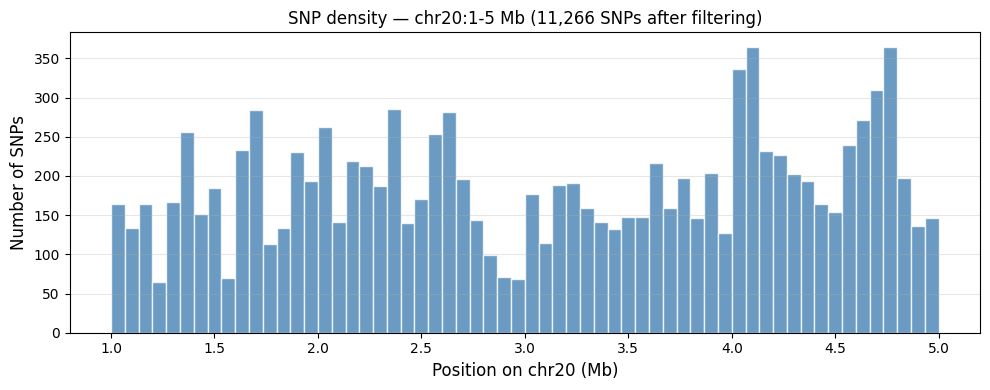

In [34]:
# Variant density across the region
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(var_df["pos"] / 1e6, bins=60, color="steelblue", edgecolor="white", alpha=0.8)
ax.set_xlabel("Position on chr20 (Mb)", fontsize=12)
ax.set_ylabel("Number of SNPs", fontsize=12)
ax.set_title(f"SNP density — chr20:1-5 Mb ({len(var_df):,} SNPs after filtering)", fontsize=12)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(work_dir / "variant_density.png", dpi=150, bbox_inches="tight")
plt.show()

In [35]:
# Print a brief run summary
coding_genes = top10[top10["region"] == "coding"]["gene"].tolist()
other_genes  = top10[top10["region"] != "coding"]["gene"].tolist()

print("=" * 60)
print("RUN SUMMARY")
print("=" * 60)
print(f"Dataset    : 1000 Genomes Phase 3, chromosome 20")
print(f"Reference  : GRCh37")
print(f"Region     : {region}")
print(f"GBR        : {gbr_samples}")
print(f"YRI        : {yri_samples}")
print()
if USE_PRECALLED:
    print("Pipeline   : Pre-called VCF used (BWA + GATK by consortium)")
    print("           : Set USE_PRECALLED=False to run full FASTQ pipeline")
else:
    print("Pipeline   : Full FASTQ -> BWA-MEM -> bcftools")
print()
print(f"Filtering  : QUAL>={min_qual}, DP>={min_depth}x/sample, MAF>={min_maf}")
print(f"SNPs kept  : {len(var_df):,}")
print()
print(f"PCA        : PC1={var_exp[0]*100:.1f}%, PC2={var_exp[1]*100:.1f}%")
print()
print(f"Top variants (AF diff > 0.3): {(freq_df['AF_diff'] > 0.3).sum()}")
print(f"  Coding genes : {coding_genes if coding_genes else 'none in this window'}")
print(f"  Non-coding   : {other_genes[:3]}")
print()
for f in sorted(work_dir.rglob("*")):
    if f.is_file() and f.suffix in [".csv", ".gz", ".png", ".txt"]:
        print(f"  {f.name}")

RUN SUMMARY
Dataset    : 1000 Genomes Phase 3, chromosome 20
Reference  : GRCh37
Region     : intergenic
GBR        : ['HG00096', 'HG00097', 'HG00099', 'HG00100', 'HG00101']
YRI        : ['NA18486', 'NA18488', 'NA18489', 'NA18498', 'NA18499']

Pipeline   : Pre-called VCF used (BWA + GATK by consortium)
           : Set USE_PRECALLED=False to run full FASTQ pipeline

Filtering  : QUAL>=30, DP>=8x/sample, MAF>=0.05
SNPs kept  : 11,266

PCA        : PC1=22.4%, PC2=12.5%

Top variants (AF diff > 0.3): 3068
  Coding genes : ['PTPRA', 'TGM3', 'RASSF2', 'VPS16', 'VPS16', 'VPS16', 'TMEM239']
  Non-coding   : ['intergenic', 'intergenic', 'intergenic']

  af_comparison.png
  allele_frequencies.csv
  chr20_phase3.vcf.gz
  HG00096_1.fastq.gz
  HG00096_2.fastq.gz
  HG00097_1.fastq.gz
  HG00097_2.fastq.gz
  HG00099_1.fastq.gz
  HG00099_2.fastq.gz
  HG00100_1.fastq.gz
  HG00100_2.fastq.gz
  HG00101_1.fastq.gz
  HG00101_2.fastq.gz
  NA18486_1.fastq.gz
  NA18486_2.fastq.gz
  NA18488_1.fastq.gz
  NA1848